In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Drop Columns

In [2]:
df = pd.read_csv('../data/forestfires.csv')

# No NULL values

# Only using columns we found may be useful based on our EDA
df = df.drop(columns = ['X', 'Y', 'rain', 'day'])
df.columns

Index(['month', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'area'], dtype='object')

### Drop Duplicates

In [3]:
df = df.drop_duplicates() 
df.duplicated().sum()

np.int64(0)

### Encode Categorical Feature

In [4]:
df = pd.get_dummies(df, columns=['month'], drop_first=True) # drop_first = True -- one category is removed to avoid dummy trap 

df.columns

Index(['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'area', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='object')

### Log Transfrom Target *(area)*

In [5]:
df['log_area'] = np.log1p(df['area'])

### Heatmap after feature engineering

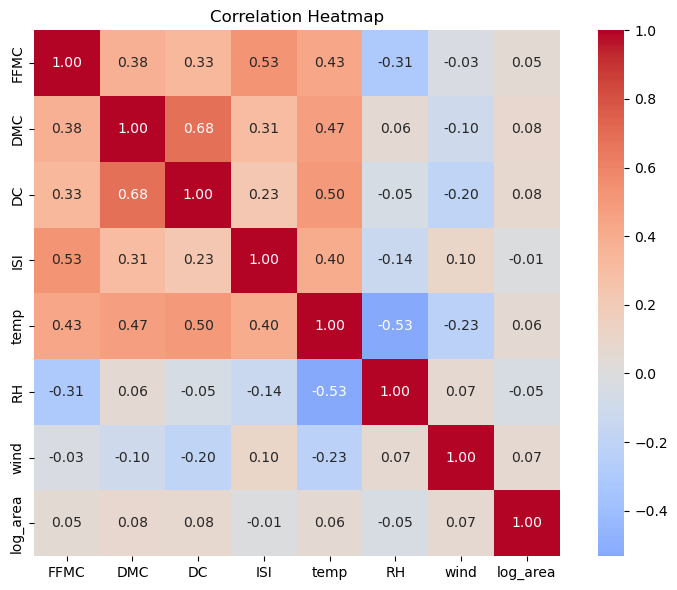

In [6]:
numerical_features = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'log_area'] #month is converted into dummy columns


corr = df[numerical_features].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

With all the feature engineering we did, the correlation of the predictors with log_area is still weak but just shows that the reality of forest fires in the specific area (Montesinho Park) during that given time (2000-2003).

### Final Check

In [7]:
print(df.isnull().sum())
print(df.duplicated().sum())

FFMC         0
DMC          0
DC           0
ISI          0
temp         0
RH           0
wind         0
area         0
month_aug    0
month_dec    0
month_feb    0
month_jan    0
month_jul    0
month_jun    0
month_mar    0
month_may    0
month_nov    0
month_oct    0
month_sep    0
log_area     0
dtype: int64
0


In [8]:
print(df.shape)
print(df.dtypes)

(509, 20)
FFMC         float64
DMC          float64
DC           float64
ISI          float64
temp         float64
RH             int64
wind         float64
area         float64
month_aug       bool
month_dec       bool
month_feb       bool
month_jan       bool
month_jul       bool
month_jun       bool
month_mar       bool
month_may       bool
month_nov       bool
month_oct       bool
month_sep       bool
log_area     float64
dtype: object


### Save new dataset to new csv file

In [9]:
df.to_csv('../data/forestfires_clean.csv', index=False)